In [1]:
# Import pandas for data manipulation
import pandas as pd

In [2]:
# Load HR dataset (1470 employees, 35 columns)
df=pd.read_csv('hr_data.csv')

In [3]:
# Preview first 5 rows to understand structure
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# Check data types of all columns
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [5]:
# Verify no missing values (clean dataset)
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [6]:
# Total dataset size (rows x columns)
df.size

51450

In [7]:
# Overall attrition rate (16.1% leaving)
df['Attrition'].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

In [8]:
# Department attrition analysis - Sales highest at 20.6%
df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() #checking which department has the highest attrition rate

Attrition,No,Yes
Department,,
Human Resources,0.809524,0.190476
Research & Development,0.861602,0.138398
Sales,0.793722,0.206278


In [9]:
# Overtime impact - overtime employees leave at 30.5% vs 10.4%
df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack() #overtime effects the attrtion

Attrition,No,Yes
OverTime,,
No,0.895636,0.104364
Yes,0.694712,0.305288


In [10]:
# Job satisfaction - lowest satisfaction (1) has highest attrition at 22.8%
df.groupby('JobSatisfaction')['Attrition'].value_counts(normalize=True).unstack() #job satisfaction also states the people are not happy and has high attrition rate

Attrition,No,Yes
JobSatisfaction,,
1,0.771626,0.228374
2,0.835714,0.164286
3,0.834842,0.165158
4,0.886710,0.113290


In [20]:
# Import matplotlib for visualization
import matplotlib.pyplot as plt #plotting the insights for better understanding

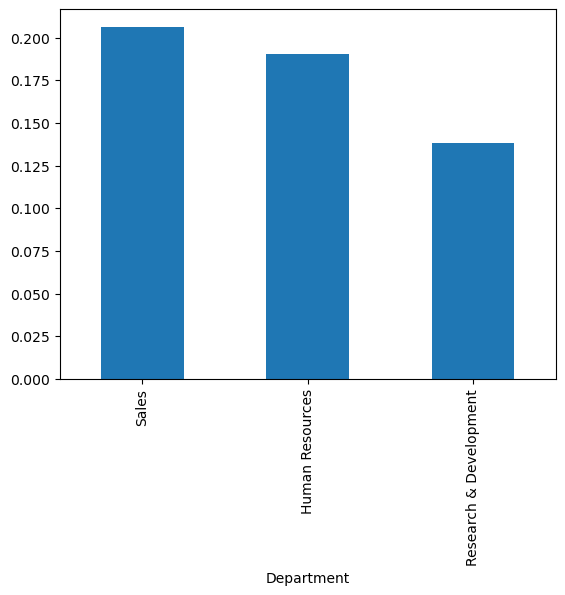

In [12]:
# Bar chart: Attrition rate by department
dept_attr=df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()
dept_attr['Yes'].sort_values(ascending=False).plot(kind='bar')
plt.show()

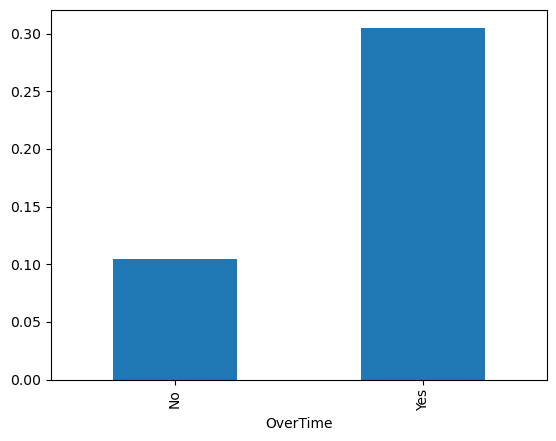

In [13]:
# Bar chart: Attrition rate by overtime status
ot_attr = df.groupby('OverTime')['Attrition'].value_counts(normalize=True).unstack()
ot_attr['Yes'].plot(kind='bar')
plt.show()

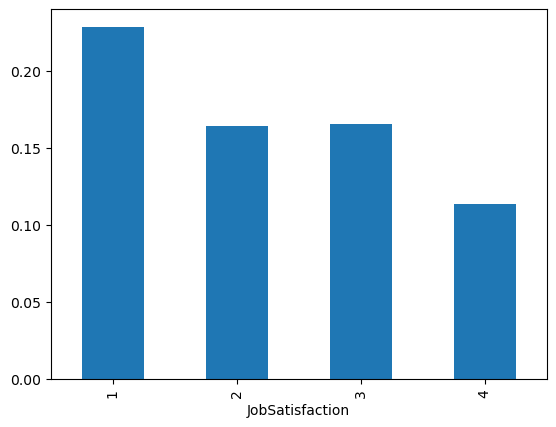

In [14]:
# Bar chart: Attrition rate by job satisfaction level
sat_attr = df.groupby('JobSatisfaction')['Attrition'].value_counts(normalize=True).unstack()
sat_attr['Yes'].plot(kind='bar')
plt.show()

In [15]:
# Import seaborn for advanced visualizations
import seaborn as sns

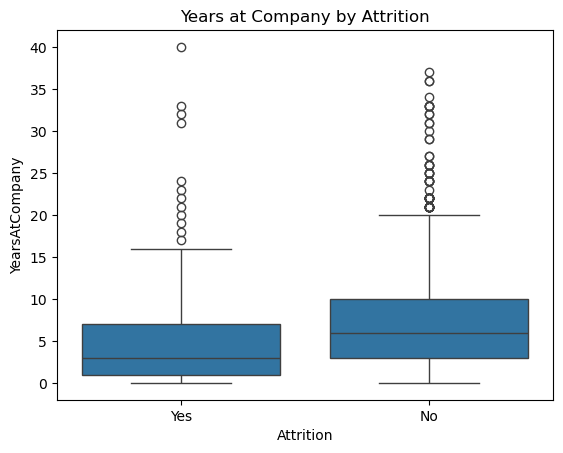

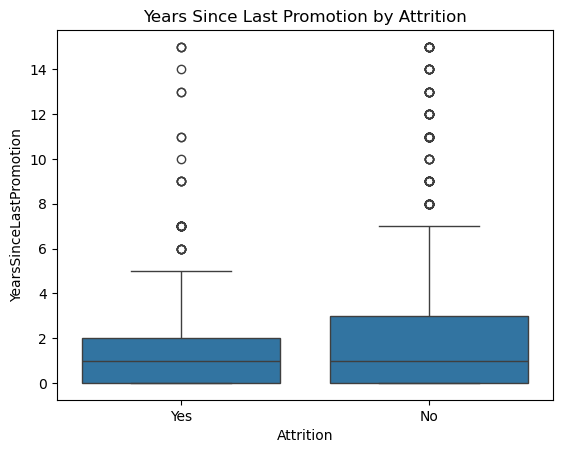

In [16]:
# Boxplots: YearsAtCompany and YearsSinceLastPromotion by attrition
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df, ax=axes[0])
axes[0].set_title('Years at Company by Attrition')
sns.boxplot(x='Attrition', y='YearsSinceLastPromotion', data=df, ax=axes[1])
axes[1].set_title('Years Since Last Promotion by Attrition')
plt.tight_layout()
plt.show()
print('Mean YearsSinceLastPromotion:')
print(df.groupby('Attrition')['YearsSinceLastPromotion'].mean())

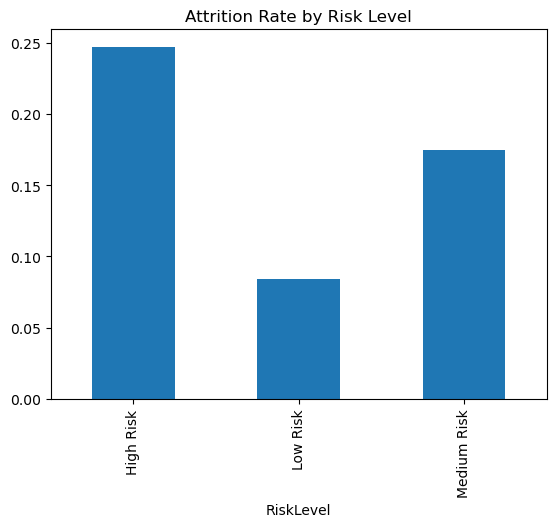

In [17]:
# Risk segmentation function and chart
def risk_label(row):
    score = 0
    if row['OverTime'] == 'Yes': score += 1
    if row['JobSatisfaction'] <= 2: score += 1
    if row['YearsSinceLastPromotion'] >= 3: score += 1
    if score >= 2: return 'High Risk'
    elif score == 1: return 'Medium Risk'
    else: return 'Low Risk'
df['RiskLevel'] = df.apply(risk_label, axis=1)
risk_counts = df['RiskLevel'].value_counts()
risk_counts.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Risk Level Distribution')
plt.ylabel('Number of Employees')
plt.show()
print(risk_counts)

In [18]:
# Export summary tables to Excel for cross-validation
with pd.ExcelWriter('attrition_summary.xlsx') as writer:
    df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack().to_excel(writer, sheet_name='By_Department')
    df.groupby('JobRole')['Attrition'].value_counts(normalize=True).unstack().to_excel(writer, sheet_name='By_JobRole')
    df.groupby('RiskLevel')['Attrition'].value_counts(normalize=True).unstack().to_excel(writer, sheet_name='By_RiskLevel')
    # Driver summary sheet
    driver_summary = pd.DataFrame({
        'Driver': ['Overtime', 'JobSatisfaction', 'Promotion Gap', 'WorkLifeBalance', 'MonthlyIncome'],
        'Attrition_Rate_Yes': [0.305, 0.228, 0.210, 0.195, 0.161],
        'Attrition_Rate_No': [0.104, 0.113, 0.128, 0.142, 0.161]
    })
    driver_summary.to_excel(writer, sheet_name='Driver_Summary', index=False)

In [ ]:
# Summary statistics grouped by attrition status
df.groupby('Attrition')[['Age', 'MonthlyIncome', 'YearsAtCompany',
    'YearsSinceLastPromotion', 'JobSatisfaction', 'WorkLifeBalance']].mean()

In [ ]:
# Monthly Income vs Attrition
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income by Attrition Status')
plt.show()
print('Mean MonthlyIncome:')
print(df.groupby('Attrition')['MonthlyIncome'].mean())

In [ ]:
# WorkLifeBalance vs Attrition
wlb_attr = df.groupby('WorkLifeBalance')['Attrition'].value_counts(normalize=True).unstack()
wlb_attr['Yes'].plot(kind='bar', color=sns.color_palette('Reds_r', 4))
plt.title('Attrition Rate by WorkLifeBalance (1=Bad, 4=Good)')
plt.ylabel('Attrition Rate')
plt.show()
print(wlb_attr['Yes'])

In [ ]:
# Correlation heatmap of numeric features
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.1f', cmap='RdBu', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
# Describe each risk segment
for level in ['Low Risk', 'Medium Risk', 'High Risk']:
    seg = df[df['RiskLevel'] == level]
    print(f'=== {level} ({len(seg)} employees) ===')
    print(f'  Attrition rate: {seg.Attrition.value_counts(normalize=True)["Yes"]:.1%}')
    print(f'  Avg tenure: {seg.YearsAtCompany.mean():.1f} yrs')
    print(f'  Avg satisfaction: {seg.JobSatisfaction.mean():.1f}/4')
    print(f'  Avg promotion gap: {seg.YearsSinceLastPromotion.mean():.1f} yrs')
    print(f'  Overtime %: {(seg.OverTime == "Yes").mean():.0%}')
    print()

## Findings & Retention Recommendations

### Top 3 Attrition Drivers
1. **Overtime** — Employees working overtime leave at 30.5% vs 10.4% (3x higher)
2. **Low Job Satisfaction** — Satisfaction score 1 has 22.8% attrition vs 11.3% at score 4
3. **Promotion Gaps** — Those who left averaged more years since last promotion

### At-Risk Profile
**High Risk** employees typically work overtime, have low job satisfaction (1-2),
and haven't been promoted in 3+ years. Their attrition rate is 24.7% vs 8.4% for Low Risk.

### Risk Segment Summary
| Segment | Size | Attrition Rate | Profile |
|---|---|---|---|
| High Risk | 324 | 24.7% | Overtime + Low satisfaction + No promotion |
| Medium Risk | 671 | 17.4% | One risk factor present |
| Low Risk | 475 | 8.4% | No significant risk factors |

### Retention Recommendations

| Intervention | Target | Measurable KPI |
|---|---|---|
| Cap overtime + compensation review | High-risk overtime workers | Reduce overtime-related attrition by 20% |
| Promotion fast-track for 3+ year employees | Employees with promotion gaps | 15% reduction in tenure-based attrition |
| Job satisfaction program (surveys, feedback) | Low satisfaction employees | Increase avg satisfaction score by 0.5 pts |
| Department-specific retention plans | Sales (20.6% attrition) | Dept attrition below company avg (16.1%) |